Text(0.5, 0, 'Frequency (THz)')

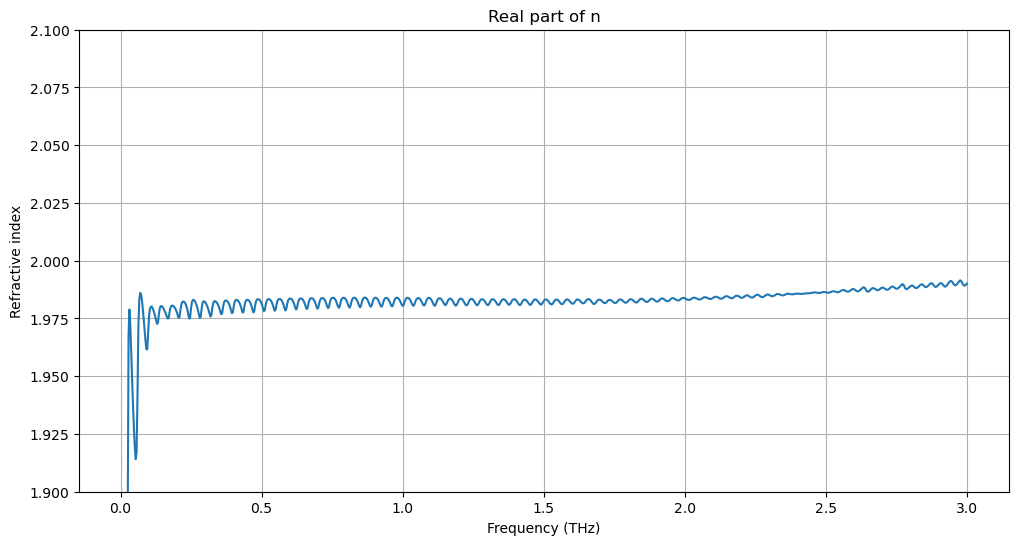

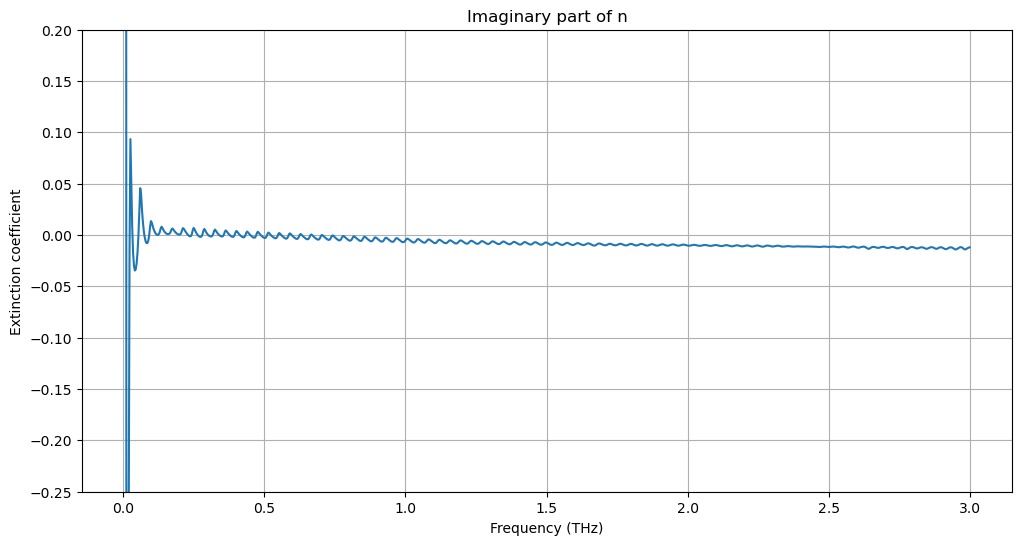

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

# LOAD DATA
datar = np.loadtxt("2mmR.dat", delimiter=",")
datas = np.loadtxt("2mmS.dat", delimiter=",")
ts = datas[:, 0]
tr = datar[:, 0]
sr = datar[:, 1]
ss = datas[:, 1]

# INTERPOLATION
startt = 0
endt = 4.6116 * 10**-11
dt = min(np.mean(np.diff(ts)), np.mean(np.diff(tr)))
t = np.arange(startt, endt + dt, dt)

sr = np.interp(t, tr, sr, left=0, right=0)
ss = np.interp(t, ts, ss, left=0, right=0)

# FFT
fftr = np.fft.fft(sr, 16384)
ffts = np.fft.fft(ss, 16384)
freq = np.fft.fftfreq(16384, dt)

# MASK
mask = (freq > 0) & (freq < 3.0 * 10**12)
fftr = fftr[mask]
ffts = ffts[mask]
freq = freq[mask]

# TRANSFER FUNCTION
tf = ffts / fftr
phase_unwrapped = np.unwrap(np.angle(tf))
phase_unwrapped -= phase_unwrapped[0]-1.9


# DEFINE FUNCTIONS
def F(n, f, lnH_exp):
    lnH_th = (np.log((4 * n) / ((1 + n) ** 2)) 
              - 1j * 2e-3 * (2 * np.pi * f) * (n - 1) / (3e8)
              + np.log(1 + ((n - 1) / (n + 1)) ** 2 * np.exp((-4 * 1j * n * np.pi * f * 2e-3) / 3e8)))
    return lnH_th - lnH_exp

def G(n, f):
    x = 1 / n - 2 / (1 + n) - 1j * 2e-3 * (2 * np.pi * f) / 3e8
    y = 2 * ((n - 1) / (n + 1)) ** 2 * np.exp((-4 * 1j * n * np.pi * f * 2e-3) / 3e8)
    s=1 + ((n - 1) / (n + 1)) ** 2 * np.exp((-4 * 1j * n * np.pi * f * 2e-3) / 3e8)
    z = 1 / (n - 1) - 1 / (n + 1) - 1j * 2e-3 * (2 * np.pi * f) / (3e8)
    return x + y * z/s

def n_r(f, lnH_exp, n_0, iterations=50, tolerance=1e-12):
    n = n_0
    for _ in range(iterations):
        F_ = F(n, f, lnH_exp)
        G_ = G(n, f)
        delta_n = F_ / G_
        n = n - delta_n
        if abs(F_/G_) < tolerance:
            break
    return n

# INITIAL GUESS & COMPUTATION
n_0 = 2 + 0.05j
n_ = []

for i, f in enumerate(freq):
    lnH_exp = np.log(np.abs(tf[i])) + 1j * phase_unwrapped[i] 
    n = n_r(f, lnH_exp, n_0) 
    n_.append(n)
    n_0=n
n_ = np.array(n_)

# COMPUTE THEORETICAL TRANSFER FUNCTION
H_th = np.exp(np.log((4 * n_) / ((1 + n_) ** 2)) 
              - 1j * 2e-3 * (2 * np.pi * freq) * (n_ - 1) / (3e8)
              + np.log(1 + ((n_ - 1) / (n_ + 1)) ** 2 * np.exp((-4 * 1j * n_ * np.pi * freq * 2e-3) / 3e8)))



# PLOT REAL OF COMPLEX REFRACTIVE INDEX
plt.figure(figsize=(12, 6))
plt.plot(freq * 10**-12, np.real(n_))
plt.title("Real part of n")
plt.xlabel("Frequency (THz)")
#plt.ylim(-0.5, 0.5)
plt.ylabel("Refractive index")
#plt.xlim(0,3)
plt.ylim(1.9,2.1)
plt.grid(True)

# PLOT IMAGINARY OF COMPLEX REFRACTIVE INDEX
plt.figure(figsize=(12, 6))
plt.plot(freq * 10**-12, np.imag(n_))
plt.ylim(-0.25, 0.2)
plt.title("Imaginary part of n")
plt.ylabel("Extinction coefficient")
plt.grid(True)
plt.xlabel("Frequency (THz)")

